# Outline 

Using different Techniques to select the Features

*But first we have perform Feature Engineering (categorical encoding and scaling)*

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
X_train = pd.read_csv('../4. Missing Values Imputation/Houses/X_train.csv',index_col=0)
X_test = pd.read_csv('../4. Missing Values Imputation/Houses/X_test.csv',index_col=0)
y_train = pd.read_csv('../4. Missing Values Imputation/Houses/y_train.csv',index_col=0)
y_test = pd.read_csv('../4. Missing Values Imputation/Houses/y_test.csv',index_col=0)

In [30]:
X_train.shape

(2878, 14)

In [31]:
y_test.shape

(1419, 1)

In [32]:
X_train.head()

,Bath(s),Area(Marla),Bedroom(s),Servant Quarters,Kitchens,Store Rooms,Storey Unit,Main Location,IsPrimeLoc,SolarInstalled,WaterBore,CornerHouse,luxury_type,Property era
906,5.0,7.0,5.0,1.0,2.0,1.0,2.0,D-12,False,False,False,False,0,Brand New (2025)
3379,6.0,10.0,5.0,1.0,2.0,1.0,2.0,Bahria Enclave,False,False,False,False,0,Brand New (2025)
2094,4.0,5.0,3.0,1.0,2.0,1.0,2.0,MPCHS - Multi Gardens,True,False,False,True,0,Brand New (2025)
218,6.0,14.0,6.0,1.0,1.0,1.0,2.0,G-9,True,False,False,False,0,Brand New (2025)
3455,5.0,4.0,5.0,1.0,2.0,1.0,2.0,G-13,True,False,False,False,0,Brand New (2025)


In [33]:
# Creating new feature 

# (Assuming a 2-storey house builds on roughly 80% of the plot footprint per floor)

X_train['Plot_Size_Sqft'] = X_train['Area(Marla)'] * 272.251
FOOTPRINT_FACTOR = 0.8
X_train['Total Built up space'] = X_train['Plot_Size_Sqft'] * FOOTPRINT_FACTOR * X_train['Storey Unit']

X_test['Plot_Size_Sqft'] = X_test['Area(Marla)'] * 272.251
FOOTPRINT_FACTOR = 0.8
X_test['Total Built up space'] = X_test['Plot_Size_Sqft'] * FOOTPRINT_FACTOR * X_test['Storey Unit']

<Axes: >

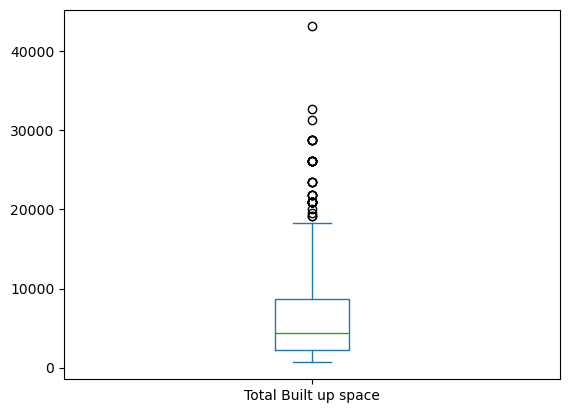

In [34]:
X_train['Total Built up space'].plot(kind='box')


- Main Location --> Binary Encoding/ Target Encoding <br>


In [35]:
from sklearn.preprocessing import OneHotEncoder,FunctionTransformer,RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from category_encoders import TargetEncoder
from sklearn import set_config

set_config(transform_output='pandas')

In [36]:
# 1. Chronological order: From oldest to future concepts
property_era_mapping = {
    'Vintage': 1,
    'Established': 2,
    'Recently Built': 3,
    'Modern Era': 4,
    'Brand New (2025)': 5,
    'Future': 6
}

X_train['Property era'] = X_train['Property era'].map(property_era_mapping)
X_test['Property era'] = X_test['Property era'].map(property_era_mapping)

In [37]:

numeric_transformer = Pipeline(steps=[
    ('Log', FunctionTransformer(np.log1p)),
    ('Scale', RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('TargetEncoding', TargetEncoder(smoothing=5, min_samples_leaf=2, handle_unknown='value'), ['Main Location']),
        ('NumericTransform', numeric_transformer, ['Area(Marla)', 'Total Built up space'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_train_transformed = preprocessor.fit_transform(X_train, y_train_log)
X_test_transformed = preprocessor.transform(X_test)

In [38]:
X_train_transformed.head()

,Main Location,Area(Marla),Total Built up space,Bath(s),Bedroom(s),Servant Quarters,Kitchens,Store Rooms,Storey Unit,IsPrimeLoc,SolarInstalled,WaterBore,CornerHouse,luxury_type,Property era,Plot_Size_Sqft
906,2.384121,-0.289869,-0.257280,5.0,5.0,1.0,2.0,1.0,2.0,False,False,False,False,0,5,1905.757
3379,1.555500,0.000000,0.000000,6.0,5.0,1.0,2.0,1.0,2.0,False,False,False,False,0,5,2722.510
2094,1.496598,-0.551729,-0.499959,4.0,3.0,1.0,2.0,1.0,2.0,True,False,False,True,0,5,1361.255
218,2.258986,0.282315,0.242726,6.0,6.0,1.0,1.0,1.0,2.0,True,False,False,False,0,5,3811.514
3455,2.012407,-0.717685,-0.660880,5.0,5.0,1.0,2.0,1.0,2.0,True,False,False,False,0,5,1089.004


In [39]:
X_test_transformed

,Main Location,Area(Marla),Total Built up space,Bath(s),Bedroom(s),Servant Quarters,Kitchens,Store Rooms,Storey Unit,IsPrimeLoc,SolarInstalled,WaterBore,CornerHouse,luxury_type,Property era,Plot_Size_Sqft
2758,1.442282,-0.551729,-0.999752,6.0,6.0,1.0,1.0,1.0,1.0,False,False,False,True,0,3,1361.255
4047,2.478524,0.152059,0.131522,6.0,5.0,1.0,2.0,1.0,2.0,False,False,False,True,0,3,3267.012
2910,1.799555,-0.086755,-0.076002,5.0,5.0,1.0,2.0,1.0,2.0,False,False,False,False,0,5,2450.259
3425,2.937143,0.588585,0.792568,8.0,8.0,2.0,2.0,2.0,3.0,False,False,False,True,0,3,5445.020
5440,2.478524,0.588585,0.500041,7.0,6.0,2.0,2.0,1.0,2.0,True,True,False,False,0,5,5445.020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,1.785877,0.000000,0.000000,7.0,5.0,1.0,2.0,1.0,2.0,False,False,False,False,0,3,2722.510
842,2.015268,0.000000,-0.499959,7.0,5.0,1.0,2.0,1.0,1.0,True,False,False,False,0,5,2722.510
5062,1.785877,0.000000,0.000000,6.0,5.0,1.0,2.0,1.0,2.0,False,False,False,False,0,5,2722.510
2120,1.759044,-0.182658,-0.160963,6.0,6.0,1.0,2.0,1.0,2.0,False,False,False,False,0,4,2178.008


In [40]:
X_train_transformed.columns

Index(['Main Location', 'Area(Marla)', 'Total Built up space', 'Bath(s)',
       'Bedroom(s)', 'Servant Quarters', 'Kitchens', 'Store Rooms',
       'Storey Unit', 'IsPrimeLoc', 'SolarInstalled', 'WaterBore',
       'CornerHouse', 'luxury_type', 'Property era', 'Plot_Size_Sqft'],
      dtype='object')

In [41]:
from sklearn.metrics import r2_score,mean_absolute_error

### 1. Random Forest Feature Importance

In [52]:
from sklearn.ensemble import RandomForestRegressor

clf = RandomForestRegressor(random_state=42)
clf.fit(X_train_transformed,y_train_log)
y_pred = clf.predict(X_test_transformed)

C:\Users\Wajih\anaconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [53]:
y_pred = np.expm1(y_pred)
print('r2 Score',r2_score(y_test,y_pred))
print('Mean absolute error',mean_absolute_error(y_test,y_pred))

r2 Score 0.9323511591005635
Mean absolute error 1.3131264623935783


In [54]:
# Importances

df1_rf = pd.DataFrame(data=clf.feature_importances_,columns=['RF Importance'],index=clf.feature_names_in_).sort_values(by='RF Importance',ascending=False)

In [55]:
df1_rf

,RF Importance
Plot_Size_Sqft,0.324946
Area(Marla),0.320144
Main Location,0.289512
Bath(s),0.024667
Bedroom(s),0.012842
Total Built up space,0.011291
Property era,0.004231
luxury_type,0.001876
Kitchens,0.001868
CornerHouse,0.001625


### 2. Gradient Boosting 

In [56]:
from sklearn.ensemble import GradientBoostingRegressor

clf = GradientBoostingRegressor(random_state=42)
clf.fit(X_train_transformed,y_train_log)
y_pred = clf.predict(X_test_transformed)

C:\Users\Wajih\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [57]:
y_pred = np.expm1(y_pred)
print('r2 Score',r2_score(y_test,y_pred))
print('Mean absolute error',mean_absolute_error(y_test,y_pred))

r2 Score 0.9349695407255895
Mean absolute error 1.4146969564023664


In [58]:
# Importances

df2_gb = pd.DataFrame(data=clf.feature_importances_,columns=['Gb Importance'],index=clf.feature_names_in_).sort_values(by='Gb Importance',ascending=False)

In [59]:
df2_gb.head()

,Gb Importance
Main Location,0.347724
Area(Marla),0.302241
Plot_Size_Sqft,0.289170
Bedroom(s),0.021655
Total Built up space,0.019954


### 3. Permutation Importances

In [60]:
y_test_log = np.log1p(y_test)

In [61]:
from sklearn.inspection import permutation_importance

rf_clf = RandomForestRegressor(random_state=42)
rf_clf.fit(X_train_transformed,y_train_log)

perm_clf = permutation_importance(rf_clf,X_test_transformed,y_test_log,n_repeats=20,random_state=42)

C:\Users\Wajih\anaconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [62]:
perm_clf.importances_mean

array([ 5.16585707e-01,  1.31526977e-01,  4.87482062e-03,  1.33424138e-02,
        1.70757095e-02,  7.49949747e-04,  4.62705346e-04,  1.56426064e-04,
       -2.39363687e-04, -2.79791060e-05,  4.00408737e-04,  2.47805220e-04,
        1.20877479e-03,  1.99605050e-04,  2.96923211e-03,  1.39761759e-01])

In [63]:
# Importances

df3_pm = pd.DataFrame(data=perm_clf.importances_mean,columns=['PM Importance'],index=X_train_transformed.columns).sort_values(by='PM Importance',ascending=False)
df3_pm.head()

,PM Importance
Main Location,0.516586
Plot_Size_Sqft,0.139762
Area(Marla),0.131527
Bedroom(s),0.017076
Bath(s),0.013342


In [64]:
X_train_transformed['Area(Marla)'].describe()

count    2878.000000
mean        0.034823
std         0.526187
min        -1.182658
25%        -0.411415
50%         0.000000
75%         0.588585
max         1.644618
Name: Area(Marla), dtype: float64

### 4. Lasso

In [65]:
from sklearn.linear_model import Lasso

clf = Lasso(alpha=0.001,random_state=42)
clf.fit(X_train_transformed,y_train_log)
y_pred = clf.predict(X_test_transformed)

In [66]:
y_pred = np.expm1(y_pred)
print('r2 Score',r2_score(y_test,y_pred))
print('Mean absolute error',mean_absolute_error(y_test,y_pred))

r2 Score 0.9240481882631053
Mean absolute error 1.6729553411975897


In [67]:
clf.coef_

array([ 6.63810094e-01,  3.98555519e-01,  7.50663689e-02,  8.17934854e-03,
        6.32038366e-02, -1.71226198e-03,  2.42820506e-02, -7.28156677e-03,
        0.00000000e+00,  1.54127753e-02,  4.40502811e-02,  5.93142137e-02,
        3.35416370e-02, -1.82353353e-03,  1.95157338e-02,  3.66288411e-05])

In [68]:
# Importances

df4_lasso =  pd.DataFrame(data=clf.coef_,columns=['Lasso Importance'],index=clf.feature_names_in_).sort_values(by='Lasso Importance',ascending=False)
df4_lasso.head()

,Lasso Importance
Main Location,0.663810
Area(Marla),0.398556
Total Built up space,0.075066
Bedroom(s),0.063204
WaterBore,0.059314


### 5. Linear Regression

In [69]:
from sklearn.linear_model import LinearRegression

clf = LinearRegression()
clf.fit(X_train_transformed,y_train_log)
y_pred = clf.predict(X_test_transformed)

In [70]:
y_pred = np.expm1(y_pred)
print('r2 Score',r2_score(y_test,y_pred))
print('Mean absolute error',mean_absolute_error(y_test,y_pred))

r2 Score 0.9248588379610272
Mean absolute error 1.6707519140627771


In [71]:
# Importances

df5_linear_reg =  pd.DataFrame(data=clf.coef_.ravel(),columns=['LR Importance'],index=clf.feature_names_in_).sort_values(by='LR Importance',ascending=False)
df5_linear_reg.head()

,LR Importance
Main Location,0.666568
Area(Marla),0.593395
Storey Unit,0.071209
WaterBore,0.068358
SolarInstalled,0.065647


### 6. RFE

In [72]:
from sklearn.feature_selection import RFE

estimator = RandomForestRegressor(random_state=42)

rfe_clf = RFE(estimator,n_features_to_select=X_train_transformed.shape[1],step=1)
rfe_clf.fit(X_train_transformed,y_train_log)


C:\Users\Wajih\anaconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestR...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",16
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of we

In [73]:
rfe_clf.estimator_.feature_importances_

array([0.28951198, 0.32014413, 0.01129085, 0.02466723, 0.01284249,
       0.00124341, 0.00186792, 0.00145109, 0.00092558, 0.00159471,
       0.00075514, 0.00102772, 0.00162511, 0.00187558, 0.00423083,
       0.32494623])

In [74]:
# Importances

df6_rfe = pd.DataFrame(data=rfe_clf.estimator_.feature_importances_,columns=['RFE Importance'],index=rfe_clf.feature_names_in_).sort_values(by='RFE Importance',ascending=False)
df6_rfe.head()

,RFE Importance
Plot_Size_Sqft,0.324946
Area(Marla),0.320144
Main Location,0.289512
Bath(s),0.024667
Bedroom(s),0.012842


### 7. Shap

In [75]:
import shap

In [76]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_transformed,y_train_log)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_transformed)

shap_sum = np.abs(shap_values).mean(axis=0)

shap_sum

C:\Users\Wajih\anaconda3\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


array([0.29109784, 0.21966212, 0.01967393, 0.03790651, 0.03337671,
       0.00276762, 0.00332013, 0.00277427, 0.00109094, 0.00336625,
       0.00265014, 0.00238381, 0.00509833, 0.00339203, 0.01698249,
       0.2214861 ])

In [77]:
df7_shap = pd.DataFrame(index=X_train_transformed.columns,columns=['SHAP_score'],data=np.abs(shap_values).mean(axis=0)).sort_values(by='SHAP_score', ascending=False)
df7_shap.head()

,SHAP_score
Main Location,0.291098
Plot_Size_Sqft,0.221486
Area(Marla),0.219662
Bath(s),0.037907
Bedroom(s),0.033377


### 8. XGBoost

In [78]:
from xgboost import XGBRegressor

clf = XGBRegressor(max_depth=2)
clf.fit(X_train_transformed,y_train_log)
y_pred = clf.predict(X_test_transformed)

In [79]:
y_pred = np.expm1(y_pred)
print('r2 Score',r2_score(y_test,y_pred))
print('Mean absolute error',mean_absolute_error(y_test,y_pred))

r2 Score 0.9382621049880981
Mean absolute error 1.3851971626281738


In [80]:
clf.feature_importances_

array([0.24010395, 0.512943  , 0.03666628, 0.12357141, 0.04835217,
       0.        , 0.00272496, 0.00389031, 0.00429184, 0.00194848,
       0.00452691, 0.00921203, 0.00417498, 0.00064532, 0.00694837,
       0.        ], dtype=float32)

In [81]:
# Importances

df8_xgb = pd.DataFrame(data=clf.feature_importances_,columns=['XGB Importance'],index=clf.feature_names_in_).sort_values(by='XGB Importance',ascending=False)
df8_xgb

,XGB Importance
Area(Marla),0.512943
Main Location,0.240104
Bath(s),0.123571
Bedroom(s),0.048352
Total Built up space,0.036666
WaterBore,0.009212
Property era,0.006948
SolarInstalled,0.004527
Storey Unit,0.004292
CornerHouse,0.004175


In [82]:
# Concatenating all feature importance dataframes
final_feature_df = pd.concat((df1_rf,df2_gb,df3_pm,df4_lasso,df5_linear_reg,df6_rfe,df7_shap,df8_xgb),axis=1)
final_feature_df

,RF Importance,Gb Importance,PM Importance,Lasso Importance,LR Importance,RFE Importance,SHAP_score,XGB Importance
Plot_Size_Sqft,0.324946,0.289170,0.139762,0.000037,0.000027,0.324946,0.221486,0.000000
Area(Marla),0.320144,0.302241,0.131527,0.398556,0.593395,0.320144,0.219662,0.512943
Main Location,0.289512,0.347724,0.516586,0.663810,0.666568,0.289512,0.291098,0.240104
Bath(s),0.024667,0.015205,0.013342,0.008179,0.007370,0.024667,0.037907,0.123571
Bedroom(s),0.012842,0.021655,0.017076,0.063204,0.059571,0.012842,0.033377,0.048352
Total Built up space,0.011291,0.019954,0.004875,0.075066,-0.085101,0.011291,0.019674,0.036666
Property era,0.004231,0.001944,0.002969,0.019516,0.020570,0.004231,0.016982,0.006948
luxury_type,0.001876,0.000002,0.000200,-0.001824,-0.007036,0.001876,0.003392,0.000645
Kitchens,0.001868,0.000087,0.000463,0.024282,0.030122,0.001868,0.003320,0.002725
CornerHouse,0.001625,0.000496,0.001209,0.033542,0.043591,0.001625,0.005098,0.004175


In [83]:
final_feature_df.abs().sum(axis=0)

RF Importance       1.000000
Gb Importance       1.000000
PM Importance       0.829830
Lasso Importance    1.415786
LR Importance       1.767797
RFE Importance      1.000000
SHAP_score          0.867029
XGB Importance      1.000000
dtype: float64

In [84]:
# Normalize the score
normalized_features_df = final_feature_df.divide(final_feature_df.abs().sum(axis=0),axis=1)

In [85]:
normalized_features_df.sum(axis=1).sort_values(ascending=False)

Main Location           2.971038
Area(Marla)             2.484499
Plot_Size_Sqft          1.362980
Bath(s)                 0.257856
Bedroom(s)              0.233105
Total Built up space    0.112649
WaterBore               0.095575
SolarInstalled          0.078241
Property era            0.065940
CornerHouse             0.063608
Storey Unit             0.047529
Kitchens                0.045125
IsPrimeLoc              0.031777
luxury_type             0.003283
Servant Quarters       -0.002217
Store Rooms            -0.003201
dtype: float64

Removing `'Servant Quarters','Kitchens','Store Rooms','luxury_type'`

and evaluate the results again

In [86]:
# Before

In [87]:
from xgboost import XGBRegressor

clf = XGBRegressor(max_depth=2)
clf.fit(X_train_transformed,y_train_log)
y_pred = clf.predict(X_test_transformed)

In [88]:
y_pred = np.expm1(y_pred)
print('r2 Score',r2_score(y_test,y_pred))
print('Mean absolute error',mean_absolute_error(y_test,y_pred))

r2 Score 0.9382621049880981
Mean absolute error 1.3851971626281738


In [89]:
X_train_transformed_removed = X_train_transformed.drop(columns=['Servant Quarters','Kitchens','Store Rooms','luxury_type'])

In [90]:
X_test_transformed_removed = X_test_transformed.drop(columns=['Servant Quarters','Kitchens','Store Rooms','luxury_type'])

In [91]:
# After
from xgboost import XGBRegressor

clf = XGBRegressor(max_depth=2)
clf.fit(X_train_transformed_removed,y_train_log)
y_pred = clf.predict(X_test_transformed_removed)

In [92]:
y_pred = np.expm1(y_pred)
print('r2 Score',r2_score(y_test,y_pred))
print('Mean absolute error',mean_absolute_error(y_test,y_pred))

r2 Score 0.9379009008407593
Mean absolute error 1.3867698907852173


In [93]:
X_train_transformed_removed.columns

Index(['Main Location', 'Area(Marla)', 'Total Built up space', 'Bath(s)',
       'Bedroom(s)', 'Storey Unit', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'Property era', 'Plot_Size_Sqft'],
      dtype='object')

In [54]:
# The results are improved a bit and our features are reduced also

# Saving the new X_train and X_test

In [94]:
X_train_transformed_removed.to_csv('X_train_houses.csv')
X_test_transformed_removed.to_csv('X_test_houses.csv')

y_test.to_csv('y_test_houses.csv')
y_train.to_csv('y_train_houses.csv')